# Exercise 1: 
### Hierarchical Clustering (Agglomerative)

For this exercise, we will be using the `Mall_Customers.csv` dataset which can be found on Kaggle, https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/data

Your task is to prepare/clean the data in `Mall_Customers.csv` and subsequently the cleaned dataset is to be used in the agglomerative clustering training process.

---

#### Load libraries
Load the necessary libraries for this exercise.

In [5]:
# import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns

#### Data Preparation / Preprocessing
Perform the necessary preprocessing steps.

In [7]:
# Load the dataset
df = pd.read_csv('Mall_Customers.csv')

In [9]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [10]:
df.shape

(200, 5)

In [11]:
# Selecting relevant features: Annual Income and Spending Score
features = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [12]:
# Standardizing the features for better clustering performance
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

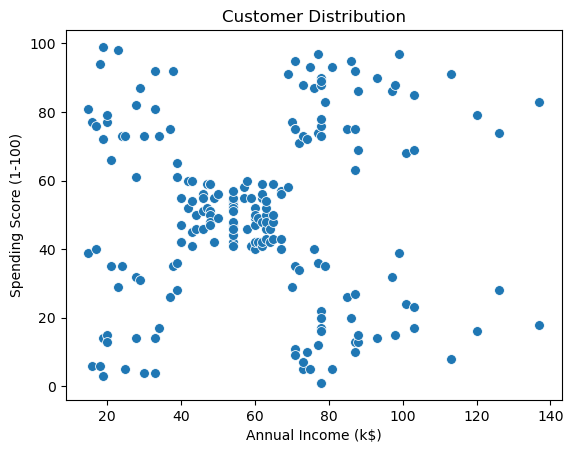

In [13]:
# Visualize the Data
sns.scatterplot(
    x=features["Annual Income (k$)"], y=features["Spending Score (1-100)"], s=50
)
plt.title("Customer Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

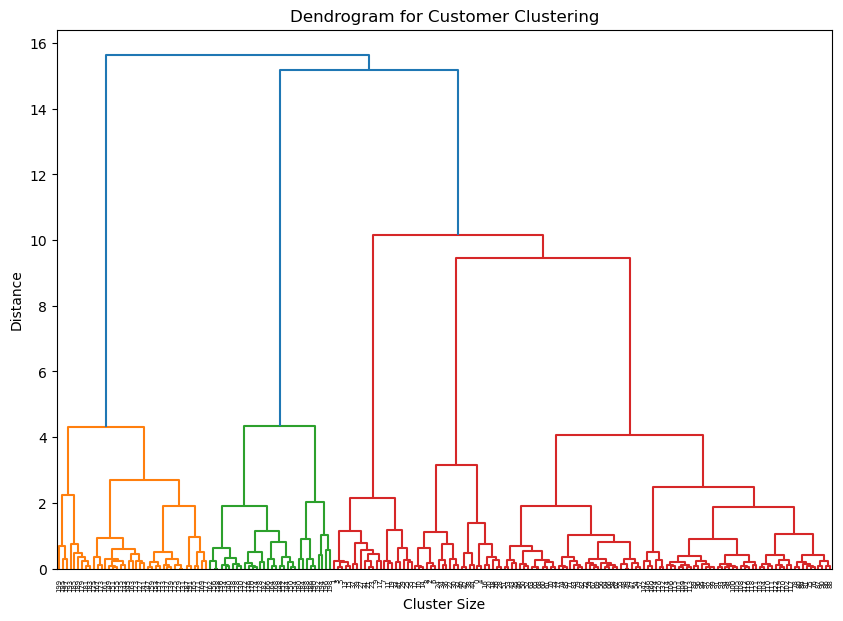

In [30]:
# Create a Dendrogram for Hierarchical Clustering
# Using Ward's method for linkage
linked = linkage(scaled_features, method="ward")

plt.figure(figsize=(10, 7))
plt.title("Dendrogram for Customer Clustering")
dendrogram(linked)
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

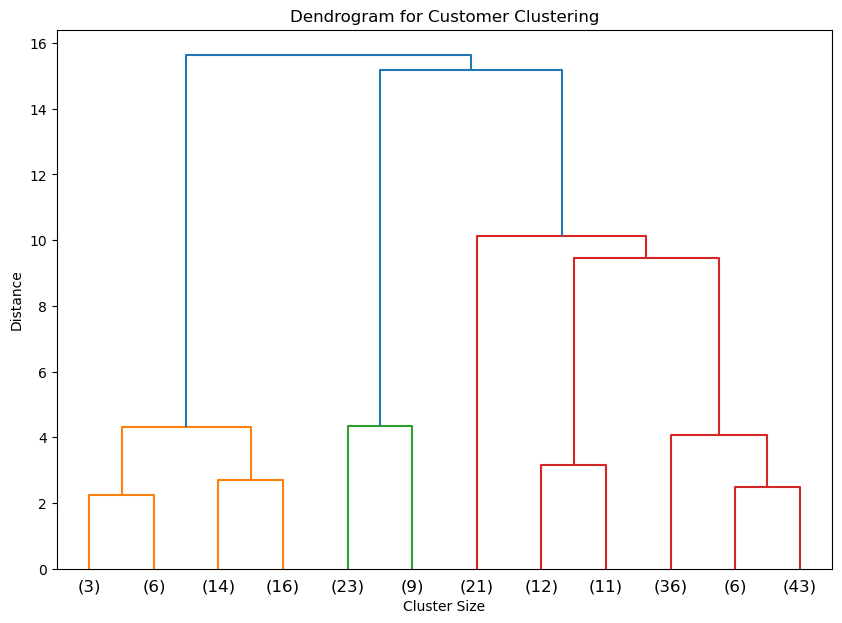

In [31]:
# Create a Dendrogram for Hierarchical Clustering
# Using Ward's method for linkage
linked = linkage(scaled_features, method="ward")

plt.figure(figsize=(10, 7))
plt.title("Dendrogram for Customer Clustering")
dendrogram(linked, truncate_mode="lastp", p=12)
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.show()

#### Model Training

In [26]:
# Choosing the number of clusters based on the dendrogram
num_clusters = 5
agglo_cluster = AgglomerativeClustering(
    n_clusters=num_clusters, metric="euclidean", linkage="ward"
)
clusters = agglo_cluster.fit_predict(scaled_features)

In [27]:
# Adding cluster labels to the dataset
df["Cluster"] = clusters

In [32]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,0
197,198,Male,32,126,74,1
198,199,Male,32,137,18,0


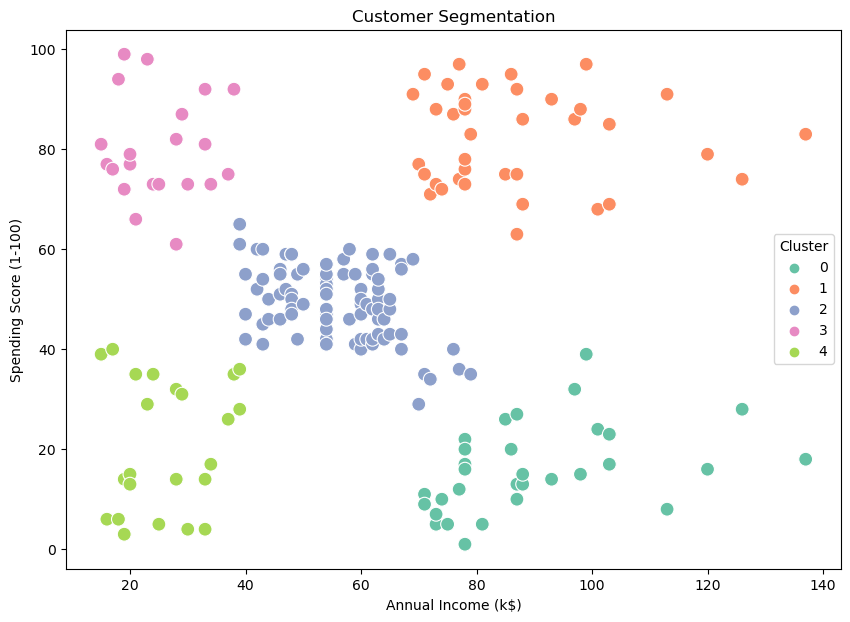

In [28]:
# Visualize Clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=features["Annual Income (k$)"],
    y=features["Spending Score (1-100)"],
    hue=df['Cluster'],
    palette='Set2',
    s=100
)
plt.title("Customer Segmentation")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.show()